In [13]:
import tensorflow as tf
from tensorflow.keras.layers import (Dense, LeakyReLU, BatchNormalization, Reshape,
     Flatten, Input)
from tensorflow.keras.models import Model, Sequential
import numpy as np
from tensorflow.keras.datasets import mnist
import matplotlib.pyplot as plt

In [7]:
#define the generator model
def b_g():
    model = Sequential()
    model.add(Dense(256, input_dim=100))
    model.add(LeakyReLU(alpha=0.2))
    model.add(BatchNormalization(momentum=0.8))
    model.add(Dense(512))
    model.add(LeakyReLU(alpha=0.2))
    model.add(BatchNormalization(momentum=0.8))
    model.add(Dense(1024))
    model.add(LeakyReLU(alpha=0.2))
    model.add(BatchNormalization(momentum=0.8))
    model.add(Dense(28 * 28 * 1, activation='tanh'))
    model.add(Reshape((28, 28, 1)))
    return model

In [4]:
#define the discriminator model
def b_d():
    model = Sequential()
    model.add(Flatten(input_shape=(28, 28, 1)))
    model.add(Dense(512))
    model.add(LeakyReLU(alpha=0.2))
    model.add(Dense(256))
    model.add(LeakyReLU(alpha=0.2))
    model.add(Dense(1, activation='sigmoid'))
    return model

In [5]:
#build and compile the discriminator
disc = b_d()
disc.compile(loss='binary_crossentropy', optimizer='adam', metrics=['accuracy'])


/home/shobhit/.local/lib/python3.9/site-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)
I0000 00:00:1759576476.300406  370902 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 2199 MB memory:  -> device: 0, name: NVIDIA GeForce GTX 1650, pci bus id: 0000:01:00.0, compute capability: 7.5
/home/shobhit/.local/lib/python3.9/site-packages/keras/src/layers/activations/leaky_relu.py:41: UserWarning: Argument `alpha` is deprecated. Use `negative_slope` instead.
  warnings.warn(


In [8]:
#build the generator and compile it
gen = b_g()

#create the GAN by stacking the generator and discriminator
gan_input = Input(shape=(100,))
generated_image = gen(gan_input)
disc.trainable = False
gan_output = disc(generated_image)
gan = Model(gan_input, gan_output)
gan.compile(loss='binary_crossentropy', optimizer='adam')


/home/shobhit/.local/lib/python3.9/site-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
/home/shobhit/.local/lib/python3.9/site-packages/keras/src/layers/activations/leaky_relu.py:41: UserWarning: Argument `alpha` is deprecated. Use `negative_slope` instead.
  warnings.warn(


In [10]:



#load the dataset and preprocess it
(x_train, _), (_, _) = mnist.load_data()
x_train = x_train / 127.5 - 1.
x_train = np.expand_dims(x_train, axis=-1)

#training parameters
batch_size = 128
epochs = 10000
sample_interval = 1000

#adversarial ground truths
real = np.ones((batch_size, 1))
fake = np.zeros((batch_size, 1))

#training loop
for epoch in range(epochs):
    #train the discriminator
    idx = np.random.randint(0, x_train.shape[0], batch_size)
    real_images = x_train[idx]
    noise = np.random.normal(0, 1, (batch_size, 100))
    generated_images = gen.predict(noise)
    d_loss_real = disc.train_on_batch(real_images, real)
    d_loss_fake = disc.train_on_batch(generated_images, fake)
    d_loss = 0.5 * np.add(d_loss_real, d_loss_fake)

    #train the generator
    noise = np.random.normal(0, 1, (batch_size, 100))
    g_loss = gan.train_on_batch(noise, real)

    #print the progress
    if epoch % sample_interval == 0:
        print(f"{epoch} [D loss: {d_loss[0]}, acc.: {100*d_loss[1]}] [G loss: {g_loss}]")

2025-10-04 16:53:58.589485: I external/local_xla/xla/service/service.cc:163] XLA service 0x7f19d8002c20 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
2025-10-04 16:53:58.589503: I external/local_xla/xla/service/service.cc:171]   StreamExecutor device (0): NVIDIA GeForce GTX 1650, Compute Capability 7.5
2025-10-04 16:53:58.595185: I tensorflow/compiler/mlir/tensorflow/utils/dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
2025-10-04 16:53:58.628113: I external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:473] Loaded cuDNN version 91002


4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step  


I0000 00:00:1759577039.019582  395647 device_compiler.h:196] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.
/home/shobhit/.local/lib/python3.9/site-packages/keras/src/backend/tensorflow/trainer.py:83: UserWarning: The model does not have any trainable weights.
  warnings.warn("The model does not have any trainable weights.")


0 [D loss: 1.0965216159820557, acc.: 8.0078125] [G loss: 0.6172270178794861]
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step 
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step 
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step 
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step 
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step 
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step 
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step 
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step 
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step 
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step 
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step 
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step 
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step 
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step 
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step 
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step 
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step 
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step 
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step 
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step 
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step 
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step 
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step 
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step 
4/4 ━━━━━━━

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step


NameError: name 'axs' is not defined

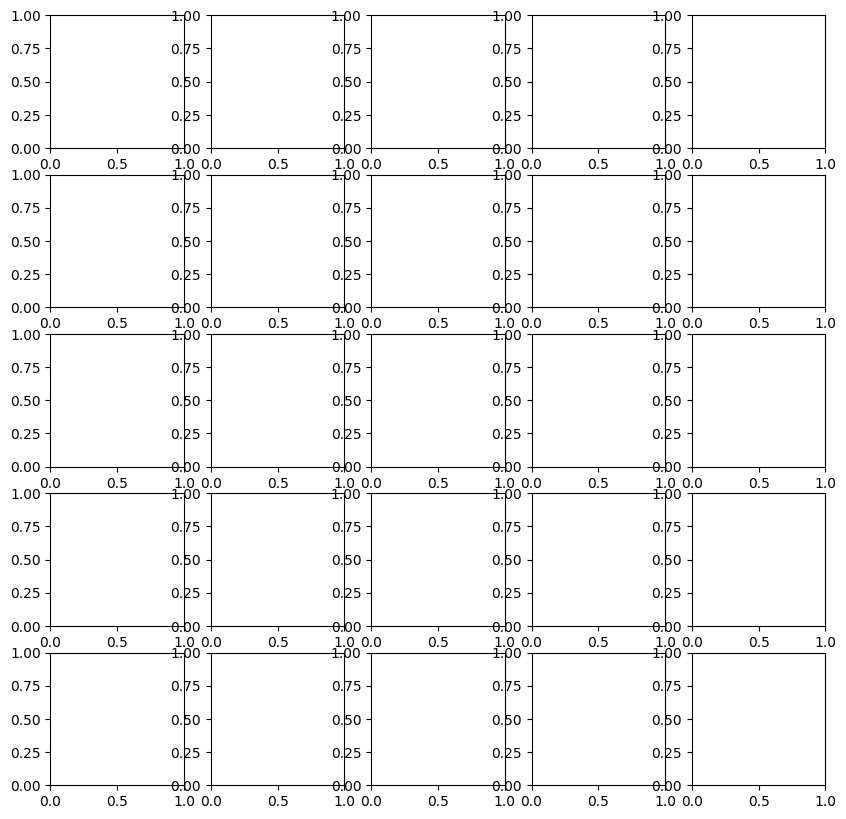

In [14]:
def sample_images(epoch):
    noise = np.random.normal(0, 1, (25, 100))
    gen_images = gen.predict(noise)
    gen_images = 0.5 * gen_images + 0.5
    fig, axis = plt.subplots(5, 5, figsize = (10, 10))
    cnt = 0
    for i in range(5):
        for j in range(5):
            axs[i,j].imshow(gen_images[cnt, :, :, 0], cmap ='gray')
            axs[i,j].axis('off')
            cnt += 1
        plt.show()

#sample images at the end of training
sample_images(epochs)